### Perplexity plot 

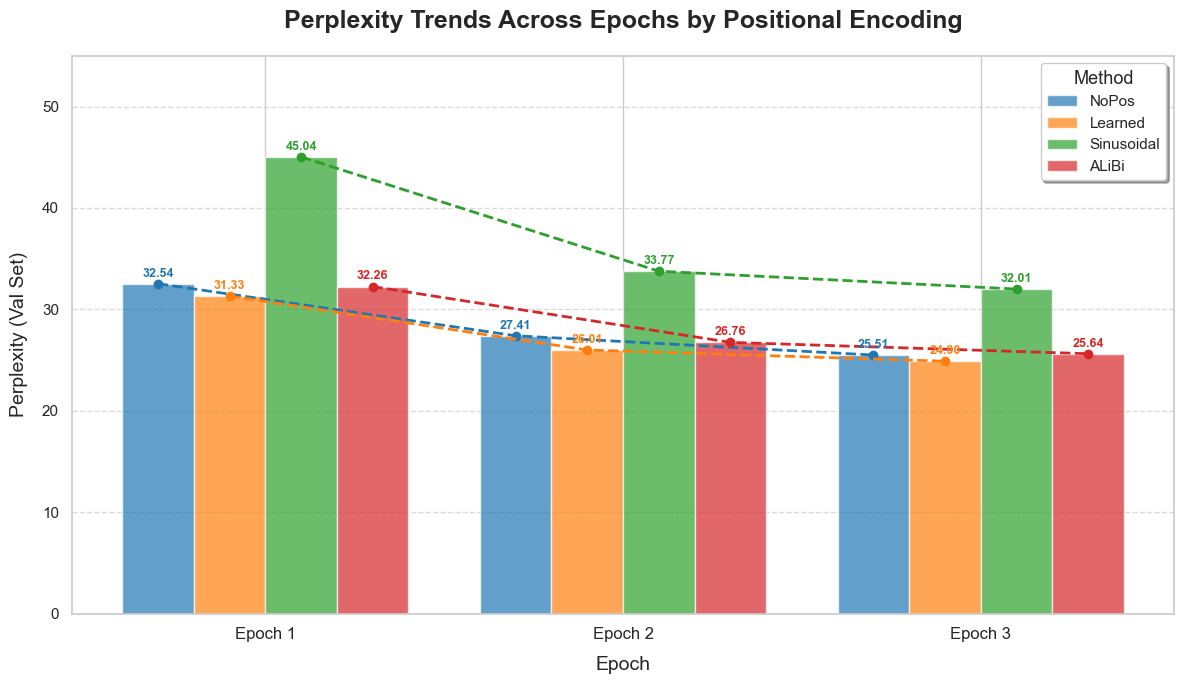

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

epochs = np.array([1, 2, 3])
data = {
    'NoPos': [32.54, 27.41, 25.51],
    'Learned': [31.33, 26.01, 24.90],
    'Sinusoidal': [45.04, 33.77, 32.01],
    'ALiBi': [32.26, 26.76, 25.64]
}

colors = {'NoPos': '#1f77b4', 'Learned': '#ff7f0e', 'Sinusoidal': '#2ca02c', 'ALiBi': '#d62728'}

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

bar_width = 0.2
x = np.arange(len(epochs))

for i, (name, values) in enumerate(data.items()):
    pos = x + (i - 1.5) * bar_width
    
    bars = ax.bar(pos, values, bar_width, label=name, color=colors[name], alpha=0.7)
    
    ax.plot(pos, values, marker='o', markersize=6, color=colors[name], linewidth=2, linestyle='--')

    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold', color=colors[name])

ax.set_title('Perplexity Trends Across Epochs by Positional Encoding', fontsize=18, pad=20, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=14, labelpad=10)
ax.set_ylabel('Perplexity (Val Set)', fontsize=14, labelpad=10)

ax.set_xticks(x)
ax.set_xticklabels([f'Epoch {e}' for e in epochs], fontsize=12)
ax.set_ylim(0, 55)  # Buffer space for top labels

ax.legend(title='Method', title_fontsize='13', fontsize='11', loc='upper right', frameon=True, shadow=True)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Text(0.5, 1.0, 'Train Loss Across Epochs by Positional Encoding')

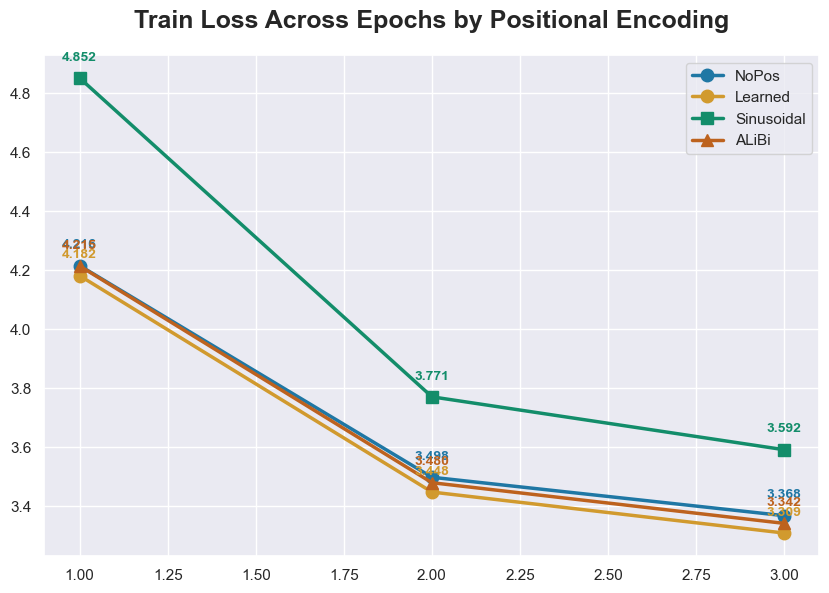

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

epochs = [1, 2, 3]
data = {
    'NoPos': [4.2159, 3.4985, 3.3682],
    'Learned': [4.1818, 3.4483, 3.3093],
    'Sinusoidal': [4.8519, 3.7712, 3.5918],
    'ALiBi': [4.2148, 3.4800, 3.3421]
}

colors = {'NoPos': '#1f77a4', 'Learned': '#d19a2e', 'Sinusoidal': '#138d6a', 'ALiBi': '#bd621e'}
markers = {'NoPos': 'o', 'Learned': 'o', 'Sinusoidal': 's', 'ALiBi': '^'}

sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6.5))

for name, values in data.items():
    plt.plot(epochs, values, marker=markers[name], markersize=9,
             label=name, color=colors[name], linewidth=2.5, linestyle='-')
    for i, val in enumerate(values):
        plt.text(epochs[i], val + 0.05, f'{val:.3f}', 
                 ha='center', va='bottom', fontsize=10, 
                 fontweight='bold', color=colors[name])
plt.legend()
plt.title("Train Loss Across Epochs by Positional Encoding", fontsize=18, pad=20, fontweight='bold')

### Mean absolute distance v/s layer

Using device: cuda

Processing NoPos...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Sinusoidal: 10 layers evaluated

Processing ALiBi...


Tokenizing and flattening:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Tokenizing and flattening:   0%|          | 0/3760 [00:00<?, ? examples/s]

Tokenizing and flattening:   0%|          | 0/4358 [00:00<?, ? examples/s]

ALiBi: 10 layers evaluated


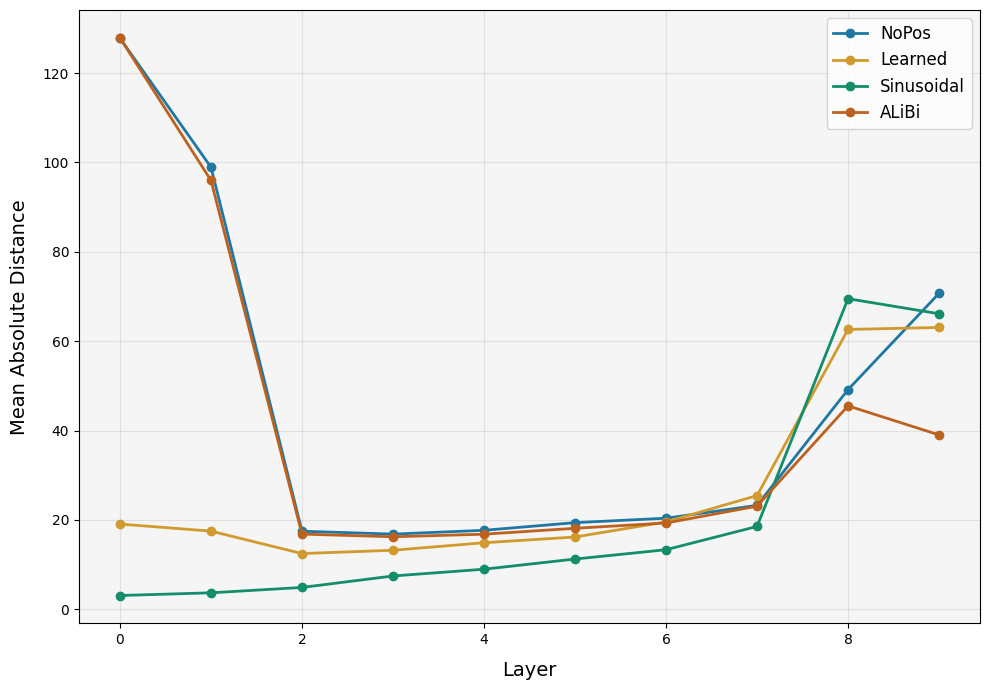


Plot generated successfully!


In [1]:
import sys
import json
from pathlib import Path
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, r'e:\no_pos_transformer\DL-proj\src')

from experiment.config import Config, DatasetConfig, ModelConfig, TrainConfig, _merge_dataclass
from experiment.model import CausalTransformerLM
from experiment.data import build_dataloaders
from experiment.utils import get_device

runs_base = Path(r'e:\no_pos_transformer\DL-proj\runs')
checkpoints = {
    'NoPos': runs_base / 'wikitext103_nopos' / 'checkpoints' / 'ckpt_3.pt',
    'Learned': runs_base / 'wikitext103_learn' / 'checkpoints' / 'last.pt',
    'Sinusoidal': runs_base / 'wikitext103_sine' / 'checkpoints' / 'last.pt',
    'ALiBi': runs_base / 'wikitext103_alibi' / 'checkpoints' / 'last.pt',
}

config_paths = {
    'NoPos': runs_base / 'wikitext103_nopos' / 'config.json',
    'Learned': runs_base / 'wikitext103_learn' / 'config.json',
    'Sinusoidal': runs_base / 'wikitext103_sine' / 'config.json',
    'ALiBi': runs_base / 'wikitext103_alibi' / 'config.json',
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

@torch.no_grad()
def evaluate_layerwise(model, dataloader, device):
    """Compute mean absolute distance of hidden states to position in each layer"""
    model.eval()
    
    all_layer_feats = None
    all_positions = []
    
    for batch in dataloader:
        # Unpack batch (input_ids, labels)
        input_ids, _ = batch
        input_ids = input_ids.to(device)
        _, hidden_states = model(input_ids, return_hidden_states=True)
        B, T = input_ids.shape
        positions = torch.arange(T, device=device).unsqueeze(0).expand(B, T)  # (B, T)
        
        if all_layer_feats is None:
            all_layer_feats = [[] for _ in range(len(hidden_states))]
        
        for l, h in enumerate(hidden_states):
            all_layer_feats[l].append(h.reshape(-1, h.size(-1)).cpu())
        
        all_positions.append(positions.reshape(-1).cpu())
    
    all_positions = torch.cat(all_positions, dim=0).float()
    layer_mae = []
    
    for l in range(len(all_layer_feats)):
        X = torch.cat(all_layer_feats[l], dim=0)
        y = all_positions
        X_aug = torch.cat([X, torch.ones(X.size(0), 1)], dim=1)
        w = torch.linalg.lstsq(X_aug, y).solution
        y_pred = X_aug @ w
        mae = torch.mean(torch.abs(y_pred - y)).item()
        layer_mae.append(mae)
    
    return layer_mae

layer_mae_results = {}

# Process each checkpoint
for label, ckpt_path in checkpoints.items():
    print(f"\nProcessing {label}...")
    
    # Load config from JSON
    with open(config_paths[label], 'r') as f:
        cfg_dict = json.load(f)
    
    # Create config object
    cfg = Config()
    _merge_dataclass(cfg, cfg_dict)
    
    # Build dataloaders
    tokenizer, train_dl, val_dl, test_dl = build_dataloaders(cfg)
    cfg.model.vocab_size = tokenizer.vocab_size
    
    # Create model
    model = CausalTransformerLM(
        vocab_size=cfg.model.vocab_size,
        d_model=cfg.model.d_model,
        n_heads=cfg.model.n_heads,
        n_layers=cfg.model.n_layers,
        d_ff=cfg.model.d_ff,
        dropout=cfg.model.dropout,
        pos_encoding=cfg.model.pos_encoding,
        tie_weights=cfg.model.tie_weights,
    ).to(device)
    
    # Load checkpoint
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state'], strict=True)
    
    # Evaluate layerwise
    layer_mae = evaluate_layerwise(model, val_dl, device)
    layer_mae_results[label] = layer_mae
    print(f"{label}: {len(layer_mae)} layers evaluated")

# Create plot
colors = {'NoPos': '#1f77a4', 'Learned': '#d19a2e', 'Sinusoidal': '#138d6a', 'ALiBi': '#bd621e'}

fig, ax = plt.subplots(figsize=(10, 7))

for label, mae_values in layer_mae_results.items():
    layers = list(range(len(mae_values)))
    ax.plot(layers, mae_values, '-o', label=label, color=colors[label], markersize=6, linewidth=2)

n_layers = len(next(iter(layer_mae_results.values())))

ax.set_xlabel('Layer', fontsize=14, labelpad=10)
ax.set_ylabel('Mean Absolute Distance', fontsize=14, labelpad=10)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f5f5f5')

plt.tight_layout()
plt.show()

print("\nPlot generated successfully!")